# Taller 2 solución

- Juan Pablo Betancur Zuluaga

- Santiago Pareja Pareja

## Actividad 1:

In [444]:
import matplotlib.pyplot as plt
import numpy as np
import control as ct

c:\Users\USUARIO\anaconda3\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


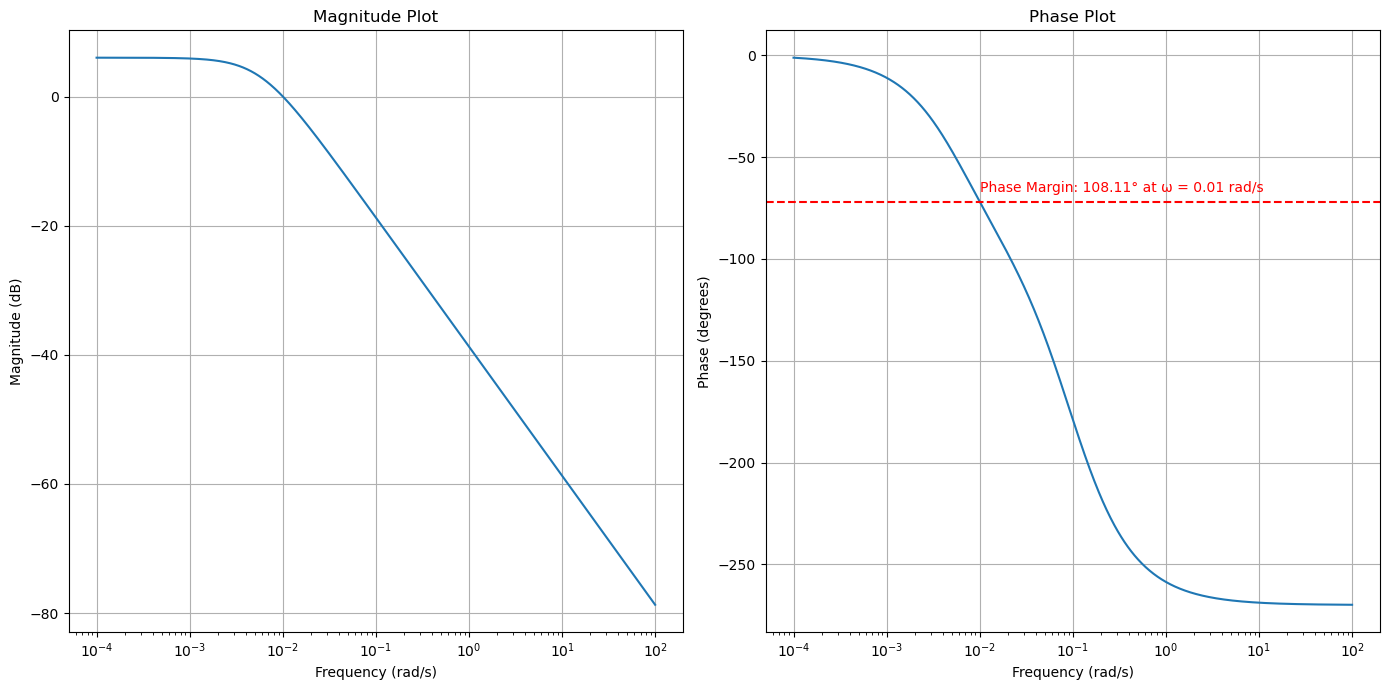

Phase Margin: 108.11° at ω = 0.01 rad/s


In [445]:
km = 2 # cambiamos la ganancia para que PM no de infinito
tau = 172.61
theta = 20.76

W_sin_tm = ct.tf([km],[tau ,1])

# Tiempo muerto
num_delay, den_delay = ct.pade(theta, 1)

# Crear función de transferencia del delay
delay_tf = ct.tf(num_delay, den_delay)

# Planta con tiempo muerto
W = W_sin_tm * delay_tf

#W = ct.tf([km],[tau ,1])
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(W, plot=False, omega = [1e-4,1e2])
phase1=phase
omega1=omega
mag1=mag
# Calculate margins for annotation
gm, pm, sm, gc = ct.margin(W)
# Frecuencia de cruce de ganancia (para PM)
_, _, _, wcp = ct.margin(W)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display
wcp1=wcp
#print(wcp)
# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

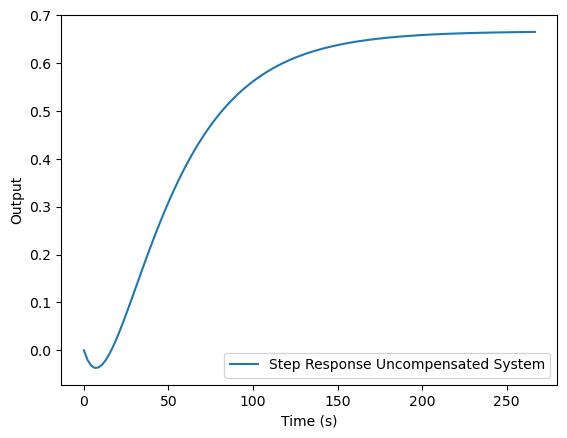

In [446]:
T, y = ct.step_response(ct.feedback(W,1))

plt.figure
plt.plot(T,y,label = 'Step Response Uncompensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

In [447]:
# Convertir GM de lineal a dB
gm_dB = 20 * np.log10(gm)

print(f"Gain Margin:     {gm:.4f} (lineal)  o  {gm_dB:.2f} dB")
print(f"Phase Margin:    {pm:.2f}°")

Gain Margin:     8.8145 (lineal)  o  18.90 dB
Phase Margin:    108.11°


El sistema si cumple con el margen de fase(PM) requerido, pero con una frecuencia de cruce muy baja, lo que implica respuesta muy lenta.

## Actividad 2: Compensador en adelanto

Se elige un **PM*** de 60°
$$
\phi_{add} = 60°-108.11° + 10°=-38.11°
$$

In [448]:
phi_add = 60 - 108.11 + 10
print(phi_add)

-38.11


### Cálculo de  $a$

El parámetro $a$ está dado por:
$$
a = \frac{1 + \sin(\phi_{add})}{1 - \sin(\phi_{add})}.
$$
Primero, convertimos $\phi_m = 26.51^\circ$ a radianes:
$$
\phi_{add} = -38.11^\circ \times \frac{\pi}{180} = -0.6651\ \text{rad}.
$$
Sustituimos en la formula de $a$:
$$
a = \frac{1 + \sin(-38.11)}{1 - \sin(-38.11)} \approx 0.2367
$$

In [449]:
phiMr=phi_add*np.pi/180
a= (1+np.sin(phiMr))/(1-np.sin(phiMr))
print(a)

0.23672590257498963


Al calcular el ángulo adicional requerido se obtiene un valor negativo, lo cual indica que no es necesario añadir fase al sistema.
Además, el parámetro a resulta menor que 1, lo que corresponde a un compensador tipo atraso y no a uno en adelanto.

Esto confirma que el sistema ya cumple con el margen de fase requerido y que un compensador en adelanto no es adecuado en este caso.

Aún así, se realiza el compensador en adelanto:

### Determinar $\omega_m$

Primero calculemos la ganancia en dB
$$
-10\log_{10}(a) = -10\log_{10}(0.2367) \approx 6.2575\ \text{dB}.
$$
Del diagrama de bode del sistema sin el compensador, se encuentra $\omega_m$ para la cual la magnitud es $6.2575$ dB.  
$$
\omega_m \approx 0.0001\ \mathrm{rad/s}.
$$

---

### Constante de tiempo $T$

Una vez se conoce $\omega_m$, se calcula $T$ como:
$$
T = \frac{1}{\omega_m \sqrt{a}}
  = \frac{1}{0.0001 \,\sqrt{0.2367}}
  \approx 20553.0893\ \mathrm{s}.
$$

In [450]:
gain_att = -10*np.log10(a)
print(gain_att)

6.257542189196274


In [451]:
# suppose mag, phase, omega are 1D numpy arrays,
# and mag is in dB (or whatever units your target is in)
mag = 20*np.log10(mag)
target = gain_att

# 1) nearest-neighbor
i = np.argmin(np.abs(mag - target))
omega_m_nearest = omega[i]
print(f"Nearest ωₘ ≃ {omega_m_nearest} rad/s")

Nearest ωₘ ≃ 0.0001 rad/s


In [452]:
T = 1/(omega_m_nearest*np.sqrt(a))
print(f"T ≈ {T:.4f} s")

T ≈ 20553.0893 s


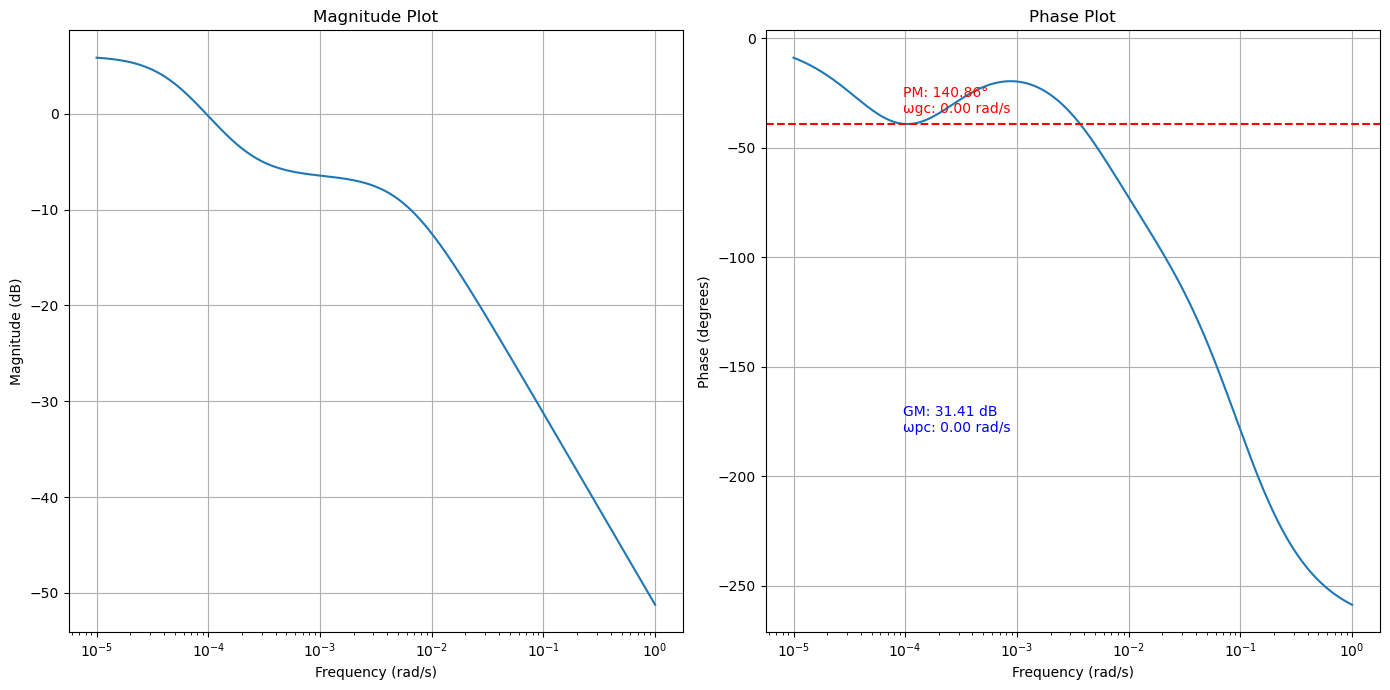

New Phase Margin (PM): 140.86° at ωgc = 0.00 rad/s
Gain Margin (GM): 37.18 (abs) | 31.41 dB at ωpc = 0.00 rad/s


In [453]:
Clead = ct.tf([a*T, 1], [T, 1])
Wcomp = Clead * W

# Generate Bode plot
mag, phase, omega = ct.bode(Wcomp, dB=True, plot=False)

# Calculate margins
gm, pm, sm, wcg = ct.margin(Wcomp)

# Frecuencia de cruce de ganancia (para PM)
_, _, _, wcp = ct.margin(Wcomp)

# Asegurar PM positivo
pm_deg = pm if pm >= 0 else pm + 360

# Convertir GM a dB
gm_db = 20 * np.log10(gm) if gm != np.inf else np.inf

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Línea del margen de fase
plt.axhline(y=-180 + pm_deg, color='r', linestyle='--')

# Texto PM
plt.text(wcp, -180 + pm_deg + 5,
         f'PM: {pm_deg:.2f}°\nωgc: {wcp:.2f} rad/s',
         color='red')

# Texto GM (opcional en fase)
if gm != np.inf:
    plt.text(wcg, -180,
             f'GM: {gm_db:.2f} dB\nωpc: {wcg:.2f} rad/s',
             color='blue')

plt.tight_layout()
plt.show()

# Print resultados finales
print(f"New Phase Margin (PM): {pm_deg:.2f}° at ωgc = {wcp:.2f} rad/s")
print(f"Gain Margin (GM): {gm:.2f} (abs) | {gm_db:.2f} dB at ωpc = {wcg:.2f} rad/s")

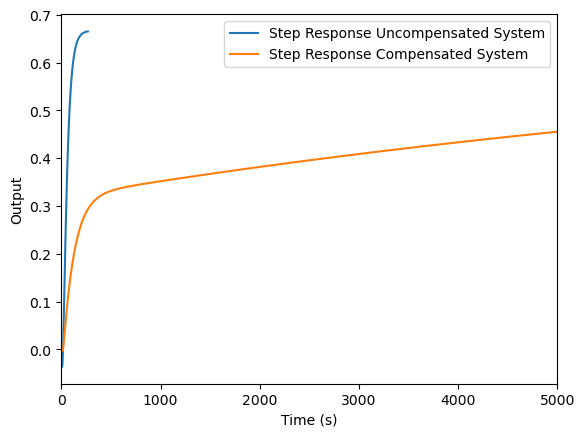

In [454]:
Wcomp=Clead*W

T1, y = ct.step_response(ct.feedback(W,1))
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1))

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.xlim(0,5000)
plt.legend()

## Actividad 3: Compensador en atraso

In [455]:
# mag, phase, omega are 1D numpy arrays of the same length
# phase in degrees, mag in dB (or linear), omega in rad/s
PM_desired = 60 - 108.11 + 5   # your target phase margin in degrees

# 1) Nearest‐neighbor approach
idx = np.argmin(np.abs(np.abs(np.rad2deg(phase1)) - PM_desired))
omega_at_PM  = omega1[idx]
mag_at_PM    = 20*np.log10(mag1[idx])
print(f"Nearest ω at PM={PM_desired}°: ω ≃ {omega_at_PM} rad/s,  mag ≃ {mag_at_PM:.3f}")


Nearest ω at PM=-43.11°: ω ≃ 0.0001 rad/s,  mag ≃ 6.019


In [456]:
float(omega_at_PM)

0.0001

In [457]:
wc=float(omega_at_PM)
Mc=float(mag_at_PM)
a=np.pow(10.0,(-Mc/20.0))
T=10/(a*wc)
Gc=ct.tf([a*T ,1],[T ,1])
print(Gc)

<TransferFunction>: sys[930]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1e+05 s + 1
  -----------
  2e+05 s + 1


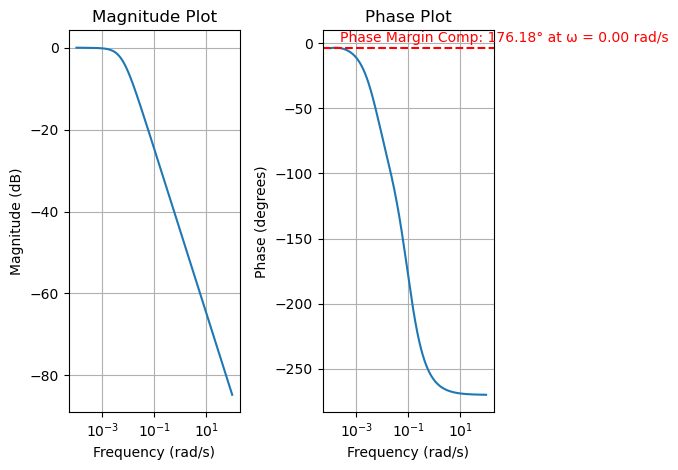

Phase Margin: 176.18° at ω = 0.00 rad/s


In [458]:
#--
Wcomp = Gc*W
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(Wcomp, plot=False, omega = [1e-4,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = ct.margin(Wcomp)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display



## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin Comp: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

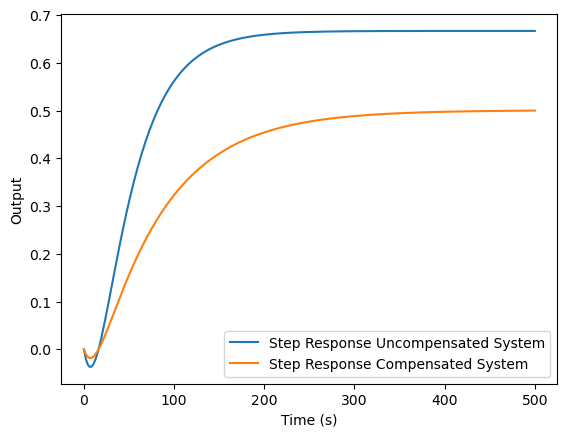

In [459]:
T1, y = ct.step_response(ct.feedback(W,1), T = 500)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 500)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

## Actividad 4: Compensador adelanto-atraso

## Actividad 5: Análisis del sistema sin compensar

### Sistema B — Parámetros iniciales

#### Cálculo de $\zeta$ a partir de $M_p = 25\%$

La relación entre el sobreimpulso porcentual y el coeficiente de amortiguamiento
para un sistema de segundo orden subamortiguado es:

$$
M_p = e^{-\pi\zeta / \sqrt{1 - \zeta^2}}
$$

Despejando $\zeta$, se toma logaritmo natural en ambos lados:

$$
\ln(M_p) = \frac{-\pi\zeta}{\sqrt{1-\zeta^2}}
$$

Definiendo $\delta = \ln(M_p) = \ln(0.25)$, se obtiene:

$$
\zeta = \frac{|\delta|}{\sqrt{\pi^2 + \delta^2}}
= \frac{|\ln(0.25)|}{\sqrt{\pi^2 + \ln^2(0.25)}}
= \frac{1.386}{\sqrt{9.870 + 1.922}}
\approx 0.404
$$

### Elección de $\omega_n = 1$ rad/s

La función de transferencia de lazo abierto del Sistema B es:

$$
L(s) = \frac{\omega_n^2}{s\,(s + 2\zeta\omega_n)}
$$

Los márgenes de estabilidad (PM y GM) dependen únicamente de la
**forma** del diagrama de Bode, no de su escala en frecuencia.
Para un sistema de segundo orden, el margen de fase satisface:

$$
PM = f(\zeta) \quad \text{(independiente de } \omega_n\text{)}
$$

ya que al normalizar $\omega \leftarrow \omega/\omega_n$, la variable
$\omega_n$ cancela algebraicamente. Por tanto, fijar $\omega_n = 1\,\text{rad/s}$
equivale a trabajar en **frecuencia normalizada**: todos los resultados
de diseño (razones de polos y ceros de los compensadores) son
directamente aplicables a cualquier $\omega_n$ real mediante reescalado.

Open Loop TF:  <TransferFunction>: sys[953]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        1
  -------------
  s^2 + 0.808 s


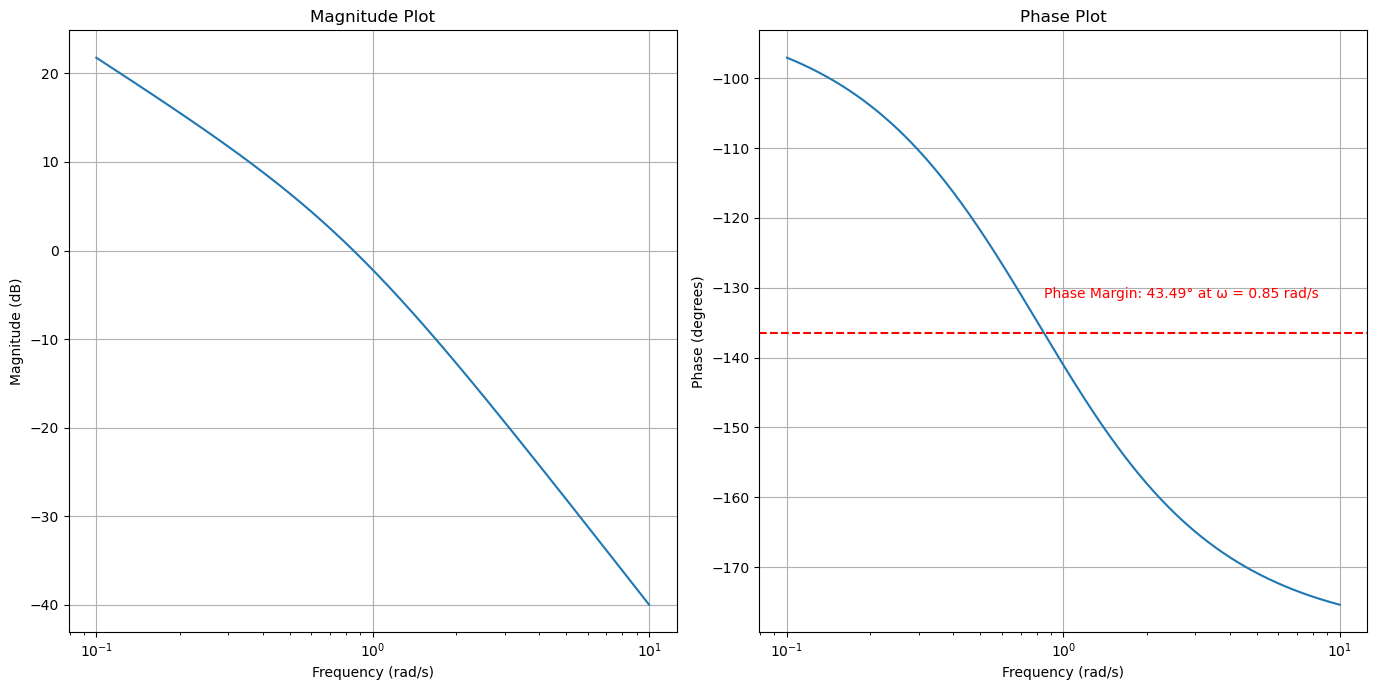

Phase Margin: 43.49° at ω = 0.85 rad/s


In [465]:
zeta = 0.404
wn = 1

L = ct.tf([wn**2], [1, 2*zeta*wn, 0])
print('Open Loop TF: ', L)

# Generate Bode plot with margins
mag, phase, omega = ct.bode(L, dB=True, plot=False)

# Calculate margins for annotation
gm, pm, sm, gc = ct.margin(L)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

El sistema necesita aumentar el PM entre $11.5°$ y $21.5°$ dependiendo del objetivo puntual que se elija dentro del rango. Esto justifica el uso de un compensador adelanto, que es lo que se hace acontuniación.

## Actividad 6: Compensador en adelanto

Se elige un **PM*** de 60°
$$
\phi_{add} = 60°-43.49° + 10°=26.51°
$$

In [466]:
phi_add = 60 - pm_deg + 10
print(phi_add)

26.510335884032855


### Cálculo de  $a$

El parámetro $a$ está dado por:
$$
a = \frac{1 + \sin(\phi_{add})}{1 - \sin(\phi_{add})}.
$$
Primero, convertimos $\phi_m = 26.51^\circ$ a radianes:
$$
\phi_{add} = 26.51^\circ \times \frac{\pi}{180} = 0.4627\ \text{rad}.
$$
Sustituimos en la formula de $a$:
$$
a = \frac{1 + \sin(26.5)}{1 - \sin(26.5)} \approx 2.6124
$$

In [467]:
phiMr=phi_add*np.pi/180
a= (1+np.sin(phiMr))/(1-np.sin(phiMr))
print(a)

2.612450838849069


### Determinar $\omega_m$

Primero calculemos la ganancia en dB
$$
-10\log_{10}(a) = -10\log_{10}(2.6124) \approx -4.1705\ \text{dB}.
$$
Del diagrama de bode del sistema sin el compensador, se encuentra $\omega_m$ para la cual la magnitud es $-4.1705$ dB.  
$$
\omega_m \approx 1.151\ \mathrm{rad/s}.
$$

---

### Constante de tiempo $T$

Una vez se conoce $\omega_m$, se calcula $T$ como:
$$
T = \frac{1}{\omega_m \sqrt{a}}
  = \frac{1}{1.51 \,\sqrt{2.6125}}
  \approx 0.5375\ \mathrm{s}.
$$

In [468]:
gain_att = -10*np.log10(a)
print(gain_att)

-4.170481266339588


In [469]:
# suppose mag, phase, omega are 1D numpy arrays,
# and mag is in dB (or whatever units your target is in)
mag = 20*np.log10(mag)
target = gain_att

# 1) nearest-neighbor
i = np.argmin(np.abs(mag - target))
omega_m_nearest = omega[i]
print(f"Nearest ωₘ ≃ {omega_m_nearest:.3f} rad/s")

Nearest ωₘ ≃ 1.151 rad/s


In [470]:
T = 1/(omega_m_nearest*np.sqrt(a))
print(f"T ≈ {T:.4f} s")

T ≈ 0.5375 s


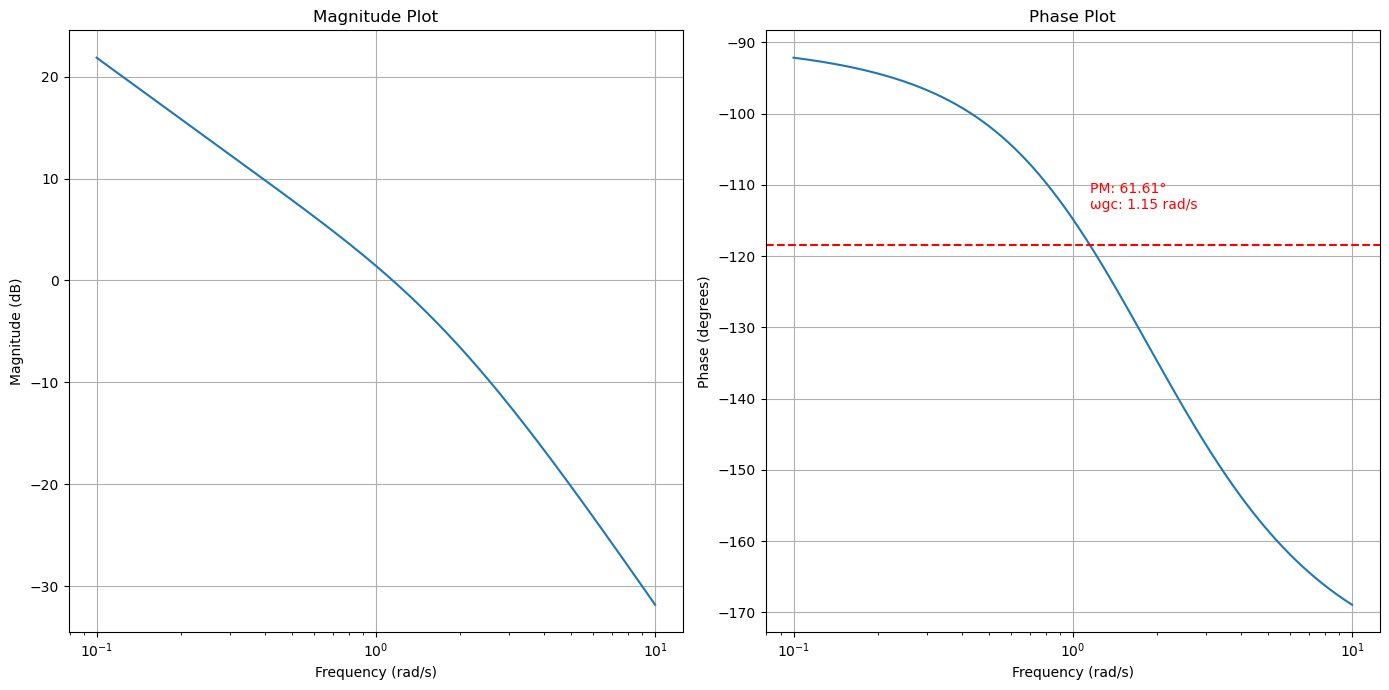

New Phase Margin (PM): 61.61° at ωgc = 1.15 rad/s
Gain Margin (GM): inf (abs) | inf dB at ωpc = 1.15 rad/s


In [471]:
Clead = ct.tf([a*T, 1], [T, 1])
Wcomp = Clead * L

# Generate Bode plot
mag, phase, omega = ct.bode(Wcomp, dB=True, plot=False)

# Calculate margins
gm, pm, sm, wcg = ct.margin(Wcomp)

# Frecuencia de cruce de ganancia (para PM)
_, _, _, wcp = ct.margin(Wcomp)

# Asegurar PM positivo
pm_deg = pm if pm >= 0 else pm + 360

# Convertir GM a dB
gm_db = 20 * np.log10(gm) if gm != np.inf else np.inf

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Línea del margen de fase
plt.axhline(y=-180 + pm_deg, color='r', linestyle='--')

# Texto PM
plt.text(wcp, -180 + pm_deg + 5,
         f'PM: {pm_deg:.2f}°\nωgc: {wcp:.2f} rad/s',
         color='red')

# Texto GM (opcional en fase)
if gm != np.inf:
    plt.text(wcg, -180,
             f'GM: {gm_db:.2f} dB\nωpc: {wcg:.2f} rad/s',
             color='blue')

plt.tight_layout()
plt.show()

# Print resultados finales
print(f"New Phase Margin (PM): {pm_deg:.2f}° at ωgc = {wcp:.2f} rad/s")
print(f"Gain Margin (GM): {gm:.2f} (abs) | {gm_db:.2f} dB at ωpc = {wcg:.2f} rad/s")

El margen de ganancia resultó infinito, ya que la fase del sistema compensado no alcanza los $−180°$
. Esto indica que el sistema presenta una alta robustez frente a variaciones en la ganancia, manteniendo la estabilidad para un amplio rango de valores de ganancia.

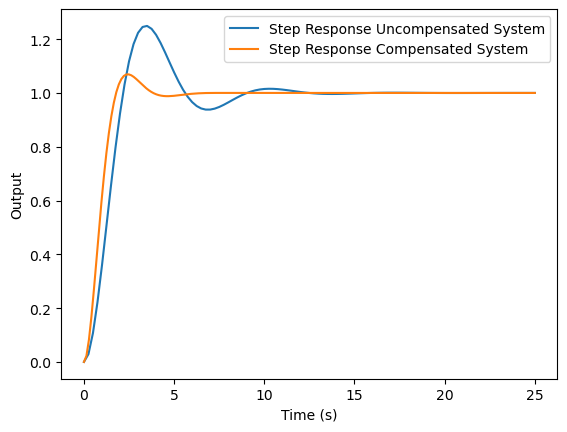

In [472]:
Wcomp=Clead*L

T1, y = ct.step_response(ct.feedback(L,1), T = 25)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

### Actividad 7: Compensador en atraso

El objetivo del compensador atraso es mejorar el comportamiento en estado estacionario del sistema, aumentando la ganancia en baja frecuencia, sin afectar significativamente el margen de fase previamente obtenido con el compensador adelanto.

Para ello, se introduce un compensador de la forma:

$$
C_{\text{lag}}(s) = \frac{s + z_l}{s + p_l}, \quad \text{con } z_l < p_l
$$

Se define el factor:

$$
\beta = \frac{p_l}{z_l} > 1
$$

Este parámetro determina el incremento en la ganancia en DC del sistema.

In [473]:
#Ganancia DC deseada
beta = 5  # o 10

Para evitar alterar el margen de fase, el compensador atraso se ubica a frecuencias mucho menores que la frecuencia de cruce de ganancia del sistema compensado con adelanto.

Se define:

$$
\omega_z = \frac{\omega_{gc}}{100}
$$

$$
\omega_p = \beta*\omega_z
$$

De esta manera, el efecto del compensador en la fase cerca de la frecuencia de cruce es mínimo.

In [474]:
omega_gc = wcp  # frecuencia de cruce obtenida en el adelanto

z_l = omega_gc / 100
p_l = z_l * beta

Con los valores definidos, se construye el compensador atraso como:

$$
C_{\text{lag}}(s) = \frac{s + z_l}{s + p_l}
$$

Este compensador incrementa la ganancia en bajas frecuencias sin modificar significativamente la dinámica del sistema.

In [475]:
Clag = ct.tf([1, z_l], [1, p_l])
print("Compensador atraso:", Clag)

Compensador atraso: <TransferFunction>: sys[967]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s + 0.0115
  -----------
  s + 0.05748


El sistema compensado total queda definido como:

$$
L_{\text{total}}(s) = C_{\text{lag}}(s)\,C_{\text{lead}}(s)\,L(s)
$$

donde:
- $ C_{\text{lead}}(s) $ mejora el margen de fase,
- $ C_{\text{lag}}(s) $ mejora la precisión en estado estacionario.

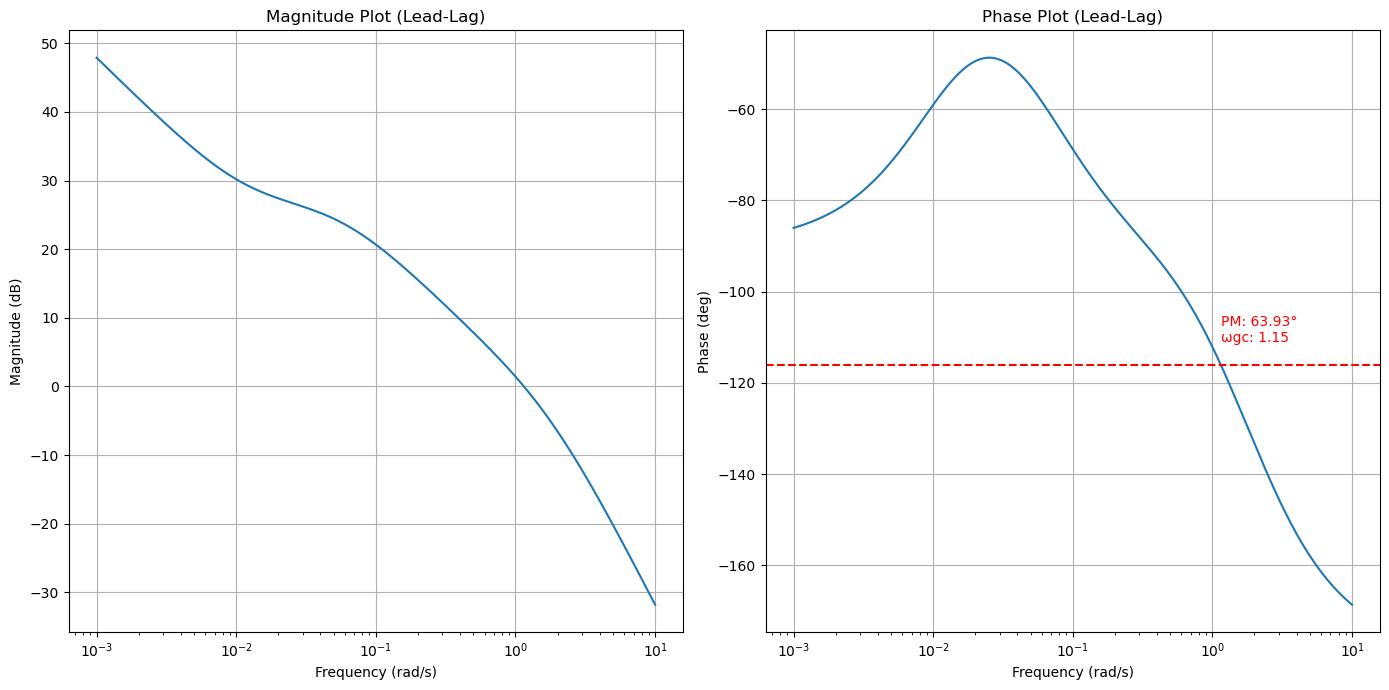

PM final: 63.93°
GM final: inf dB
Nueva ωgc: 1.15 rad/s


In [476]:
W_total = Clag * Clead * L

# Bode
mag, phase, omega = ct.bode(W_total, dB=True, plot=False)

# Márgenes
gm, pm, sm, wcg = ct.margin(W_total)
pm_deg = pm if pm >= 0 else pm + 360
gm_db = 20*np.log10(gm) if gm != np.inf else np.inf

# Frecuencia de cruce de ganancia
_, _, _, wcp_new = ct.margin(W_total)

# Plot
plt.figure(figsize=(14,7))

# Magnitud
plt.subplot(1,2,1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot (Lead-Lag)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Fase
plt.subplot(1,2,2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot (Lead-Lag)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (deg)')
plt.grid(True)

# Anotaciones
plt.axhline(y=-180 + pm_deg, color='r', linestyle='--')
plt.text(wcp_new, -180 + pm_deg + 5,
         f'PM: {pm_deg:.2f}°\nωgc: {wcp_new:.2f}',
         color='red')

if gm != np.inf:
    plt.text(wcg, -180,
             f'GM: {gm_db:.2f} dB',
             color='blue')

plt.tight_layout()
plt.show()

# Print final
print(f"PM final: {pm_deg:.2f}°")
print(f"GM final: {gm_db:.2f} dB")
print(f"Nueva ωgc: {wcp_new:.2f} rad/s")

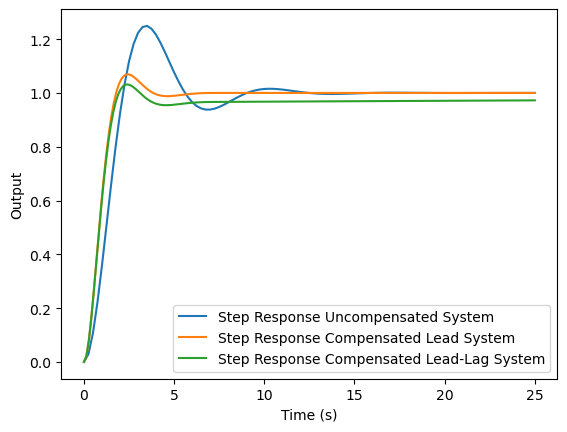

In [477]:
W_total = Clag * Clead * L

T1, y = ct.step_response(ct.feedback(L,1), T = 25)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 25)
T3, ytotal = ct.step_response(ct.feedback(W_total,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated Lead System')
plt.plot(T3,ytotal,label = 'Step Response Compensated Lead-Lag System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

### Actividad 8: Compensador adelanto-atraso

El compensador adelanto-atraso se construye como la combinación de un compensador adelanto y uno atraso:

$$
C_{\text{lead-lag}}(s) = C_{\text{lead}}(s)\,C_{\text{lag}}(s)
$$

El compensador adelanto permite aumentar el margen de fase y mejorar la respuesta transitoria, mientras que el compensador atraso incrementa la ganancia en bajas frecuencias, reduciendo el error en estado estacionario.

El sistema compensado final queda:

$$
L_{\text{final}}(s) = C_{\text{lead-lag}}(s)\,L(s)
$$

In [478]:
C_total = Clag * Clead
W_final = C_total * L

In [479]:
# Márgenes
gm, pm, sm, wcg = ct.margin(W_final)
pm_deg = pm if pm >= 0 else pm + 360
gm_db = 20*np.log10(gm) if gm != np.inf else np.inf

# Frecuencia de cruce de ganancia
_, _, _, wcp = ct.margin(W_final)

# Banda ancha (aprox: -3 dB)
mag, phase, omega = ct.bode(W_final, dB=True, plot=False)
mag_db = 20*np.log10(mag)

# encontrar ancho de banda
idx_bw = np.where(mag_db <= -3)[0]
bw = omega[idx_bw[0]] if len(idx_bw) > 0 else None

print(f"PM final: {pm_deg:.2f}°")
print(f"GM final: {gm_db:.2f} dB")
print(f"ωgc: {wcp:.2f} rad/s")
print(f"Banda ancha: {bw:.2f} rad/s")

PM final: 63.93°
GM final: inf dB
ωgc: 1.15 rad/s
Banda ancha: 1.51 rad/s


El compensador adelanto-atraso permite cumplir simultáneamente con los objetivos de diseño. El margen de fase se mantiene dentro del rango deseado, garantizando una respuesta transitoria adecuada, mientras que el compensador atraso mejora la precisión en estado estacionario.

Adicionalmente, la frecuencia de cruce se conserva aproximadamente constante, y el sistema presenta un margen de ganancia infinito, lo cual indica alta robustez frente a variaciones en la ganancia.